In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("08-seismic_activity_svm.csv")

In [3]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


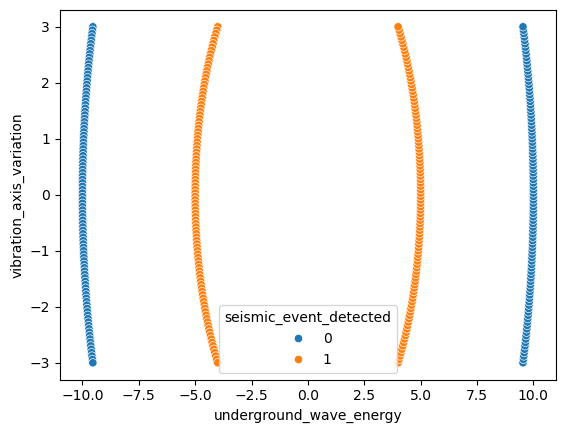

In [5]:
sns.scatterplot(x=df["underground_wave_energy"] , y=df["vibration_axis_variation"], hue = df["seismic_event_detected"])
plt.show()

In [6]:
X = df[["underground_wave_energy", "vibration_axis_variation"]].values
y = df["seismic_event_detected"].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)


In [8]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)


In [9]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


torch.Size([320, 2]) torch.Size([80, 2])
torch.Size([320, 1]) torch.Size([80, 1])


In [10]:
from torch import nn

In [11]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(in_features= 2, out_features=4)
        self.layer2 = nn.Linear(in_features= 4, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer2(self.relu(self.layer1(x)))

In [12]:
model = Model()

In [13]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr = 0.01)

In [14]:
def calculate_acc(y_test,y_pred):
    correct = torch.eq(y_test,y_pred).sum().item()
    acc = (correct / len(y_test)) * 100
    return acc

In [15]:
torch.manual_seed(42)
epochs = 200

for epoch in range(epochs):
    model.train()
    y_logits = model(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = calculate_acc(y_test = y_train ,y_pred= y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_acc(y_test = y_test ,y_pred= test_pred)

        if epoch % 10 == 0:
            print(f"Epoch: {epoch}, Loss: {loss}, Accuracy: {acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}")


Epoch: 0, Loss: 0.8934524655342102, Accuracy: 47.5, Test Loss: 0.9285216331481934, Test Accuracy: 52.5
Epoch: 10, Loss: 0.730161190032959, Accuracy: 49.0625, Test Loss: 0.7211262583732605, Test Accuracy: 42.5
Epoch: 20, Loss: 0.6671024560928345, Accuracy: 42.8125, Test Loss: 0.6501160264015198, Test Accuracy: 55.00000000000001
Epoch: 30, Loss: 0.628234326839447, Accuracy: 50.9375, Test Loss: 0.6119288206100464, Test Accuracy: 56.25
Epoch: 40, Loss: 0.5925671458244324, Accuracy: 53.43750000000001, Test Loss: 0.5764157176017761, Test Accuracy: 57.49999999999999
Epoch: 50, Loss: 0.5571832656860352, Accuracy: 55.00000000000001, Test Loss: 0.5413873195648193, Test Accuracy: 60.0
Epoch: 60, Loss: 0.5217718482017517, Accuracy: 63.74999999999999, Test Loss: 0.5072565078735352, Test Accuracy: 61.25000000000001
Epoch: 70, Loss: 0.4870804250240326, Accuracy: 72.5, Test Loss: 0.47639521956443787, Test Accuracy: 70.0
Epoch: 80, Loss: 0.45212817192077637, Accuracy: 90.625, Test Loss: 0.4464751780033

In [18]:
def plot_nonlinear_decision_boundary(model, X, y):

    # Grid alanını tanımla (tüm veri aralığını kapsasın)
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Grid'i modele sokmak için tensor'a çevir
    grid_points = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )

    # Tahmin al
    model.eval()
    with torch.inference_mode():
        logits = model(grid_points)
        preds = torch.sigmoid(logits).numpy().reshape(xx.shape)  # probability map

    # Decision boundary çizimi (0.5 threshold)
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    
    # Gerçek noktalar
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=30, edgecolor="k")
    plt.xlabel("underground_wave_energy")
    plt.ylabel("vibration_axis_variation")
    plt.title("Non-linear Decision Boundary")

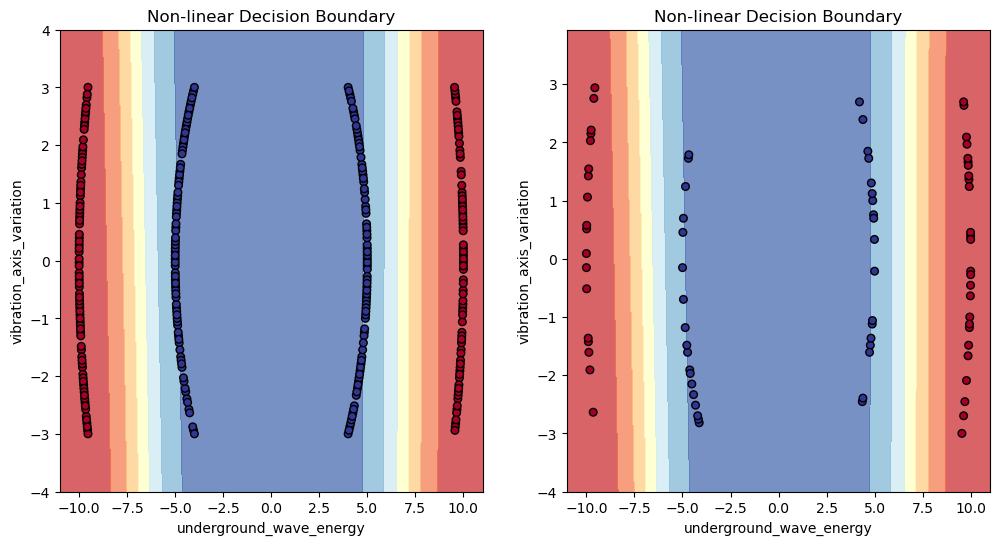

In [20]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_nonlinear_decision_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_nonlinear_decision_boundary(model, X_test, y_test)

plt.show()